# Imports

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft, rfftfreq
from IPython.display import display, clear_output
from statistics import variance

# Helper Functions

In [2]:
def make_k_omega_grid(x, g=9.81):
    """Generate k-space grid and omega following deep water dispersion."""
    x = np.asarray(x).ravel()
    N = x.size
    dx = x[1] - x[0]
    k = 2 * np.pi * rfftfreq(N, d=dx)   # k>=0
    omega = np.sqrt(g * np.abs(k))      # deep water dispersion relation
    return k, omega, dx


def new_filter(Nx, cutoff_frac=0.5, damp_strength=0.001):
    # kmax = k nyquist
    kmax  = (Nx//2)
    kc    =  cutoff_frac * kmax

    # Gaussian profile
    gauss = np.exp(-damp_strength*(np.arange(Nx//2+1)/kc)**2)

    # Set cut-off area to 0
    m       = Nx//2 + 1
    cutoff  = int(np.clip(cutoff_frac, 0.0, 1.0) * (m-1))
    mask    = np.zeros(m, dtype=float)
    mask[:cutoff+1] = 1.0

    return mask * gauss

def lwt_step_eta(eta, omega, k, dt, hat_mask=None):
    """Propagate wave surface forward in time via LWT."""
    N = eta.size
    eh = rfft(eta)

    if hat_mask is not None:
        eh *= hat_mask

    a = (2 / N) * np.abs(eh)        # Amplitudes
    Us = np.sum(a**2 * k * omega)   # Stokes Drift Magnitude
    eh *= np.exp(-1j * (omega + 0.5 * Us * k) * dt)
    return irfft(eh, n=N)

def gaspari_cohn(r):
    """Gaspari-Cohn tapering function."""
    r = np.abs(r)
    out = np.zeros_like(r)
    mask_a = r <= 1.0
    mask_b = (r > 1.0) & (r < 2.0)
    ra = r[mask_a]
    rb = r[mask_b]
    out[mask_a] = 1 - (5/3)*ra**2 + (5/8)*ra**3 + 0.5*ra**4 - 0.25*ra**5
    out[mask_b] = ((2 - rb)**5) / 12.0
    return np.clip(out, 0.0, 1.0)

def periodic_dist(a, b, L):
    """Distance in periodic domain."""
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    return ((a[:, None] - b[None, :]) + 0.5 * L) % L - 0.5 * L

def enkf_update_eta(X, y_obs, R, *, x_grid, idx_obs, Lc=None, rng=None):
    """EnKF Analysis Step."""
    N, Ne = X.shape
    M = idx_obs.size
    if rng is None: rng = np.random.default_rng()

    # Analysis Step
    Yf = X[idx_obs, :]                                         # Forecast at probe locations (M, Ne)
    xf = X.mean(axis=1, keepdims=True)                         # Ensemble mean (N,1)
    yf = Yf.mean(axis=1, keepdims=True)                        # Ensemble mean at probe locations (M,1)
    A = X - xf                                                 # Distance from mean
    D = Yf - yf                                                # Distance from mean at ensemble locations
    Eps = rng.multivariate_normal(np.zeros(M), R, size=Ne).T   # Measurement Noise with covariance R
    Ytil = y_obs.reshape(M, 1) + Eps                           # Perturbed Observations
    S = (D @ D.T) / (Ne - 1) + R                               # Innovation Covariance 
    Cxo = (A @ D.T) / (Ne - 1)                                 # Cross Covariance

    if Lc is not None:                                         # Localization
        L = N * (x_grid[1] - x_grid[0])
        d = periodic_dist(x_grid, x_grid[idx_obs], L) / Lc
        rho = gaspari_cohn(d)
        Cxo = Cxo * rho
    
    K = Cxo @ np.linalg.solve(S, np.eye(M))                    # Calculate Kalman Gain
    return X + K @ (Ytil - Yf)                                 # Calculate Updated State


def run_once_and_get_rmse(data_dir, n_cycles=1500, *, INFL=1.015, Lc_frac=0.1,
                          use_loc=True, Ne=100, sigma_eta=0.01, cutoff=0.8,
                          damping=0.0015, x_obs=np.array([125, 375, 625, 875]), seed=0,
                          filter_cap=None):
    global k, N  # Globals

    eta_true = np.load(os.path.join(data_dir, 'wavefield_eta_data.npy'))
    t = np.load(os.path.join(data_dir, 'solution_times.npy'))
    x = np.load(os.path.join(data_dir, 'x_coordinates.npy'))

    # Reference
    ETA_TRUE_XT     = np.asarray(eta_true[:, 0, :])   # (N, Nt)

    # Setup From data
    x   = np.asarray(x).ravel()
    N   = x.size
    k, omega, dx = make_k_omega_grid(x, g=9.81)
    Lx  = dx * N
    Hs  = 4*np.sqrt(np.var(ETA_TRUE_XT[:,0]))         # Calculate Hs from data

    steepness = 2*np.pi**2*Hs/(9.81*8**2)

    # Time
    dt  = t[1] - t[0]
    Nt  = eta_true.shape[-1]
    n_cycles = min(n_cycles, Nt-1)

    # Probes
    idx_obs = np.round(x_obs / dx).astype(int) % N
    M       = idx_obs.size

    # DA params
    Lc      = Lx * Lc_frac
    R       = (sigma_eta**2) * np.eye(M)

    # Init ensemble
    rng     = np.random.default_rng(seed)
    X       = Hs/20 * rng.normal(size=(N, Ne))
    X      -= X.mean(axis=0, keepdims=True)

    # Filter
    if filter_cap is not None:
        hat_mask = new_filter(N, cutoff_frac=cutoff, damp_strength=np.maximum(filter_cap, damping*Hs**2))
    else:
        hat_mask = new_filter(N, cutoff_frac=cutoff, damp_strength=damping*Hs**2)

    # DA loop
    rmse_hist = []
    mae_hist = []

    inflation = INFL

    for n in range(n_cycles):
        # Forecast
        for j in range(Ne):
            X[:, j] = lwt_step_eta(X[:, j], omega, k, dt, hat_mask=hat_mask)

        # Truth & noisy obs
        eta_t = ETA_TRUE_XT[:, n+1].copy()
        y_obs = eta_t[idx_obs] + rng.normal(0.0, sigma_eta, size=M)

        # EnKF update
        X = enkf_update_eta(X, y_obs, R, x_grid=x, idx_obs=idx_obs,
                            Lc=Lc, rng=rng)

        # Inflation & zero-mean
        mu = X.mean(axis=1, keepdims=True)
        X  = mu + inflation*(X - mu)
        X -= X.mean(axis=0, keepdims=True)

        ens_mean = X.mean(axis=1)
        
        rmse = np.sqrt(np.mean((ens_mean - eta_t)**2))/Hs
        mae = np.mean(np.abs(ens_mean - eta_t))/Hs
        spr = np.sqrt(np.mean(np.var(X[:, :], axis=1, ddof=1)))/Hs

        if spr > rmse:
            inflation = 1.0
        else:
            inflation = INFL

        rmse_hist.append(rmse)
        mae_hist.append(mae)

    return t[:n_cycles], np.asarray(rmse_hist), np.asarray(mae_hist)


# Main Loop

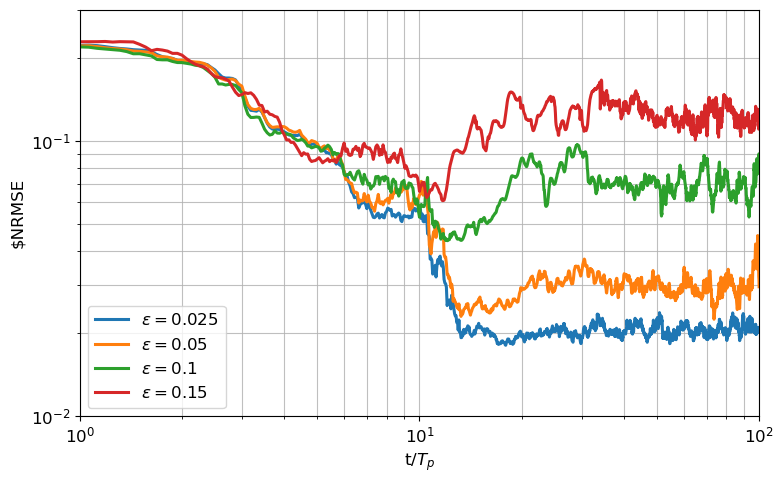

In [ ]:
# Data directories
DATASETS = [
    #"../../numpy data/Hs_0",
    "data/Hs_1_256_L",
    "data/Hs_2_256_L",
    "data/Hs_3_256_L",
    "data/Hs_4_256_L",
]
TRIALS   = list(range(0, 1))   # average over trial_0 ... trial_4
SUBDIR   = "GT_HOSM4"

# Main loop
all_results = {}   # {ds_name: {trial: (t, rmse_hist)}}
for ds in DATASETS:
    ds_name = os.path.basename(ds.rstrip("/"))
    all_results[ds_name] = {}

    for tr in TRIALS:
        data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)
        t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
            data_dir,
            n_cycles=1600,          
            INFL=1.015, Lc_frac=0.1, use_loc=True,
            Ne=100, sigma_eta=0.01, cutoff=0.8, damping=0.0015,
            x_obs=np.array([125, 375, 625, 875]),
            seed=tr,                
        )
        all_results[ds_name][tr] = (t_vec, rmse_hist, mae_hist)

# Plot
plt.figure(figsize=(8.0, 5))
labels = {'Hs_1_256_L': rf"$\varepsilon=0.025$", 'Hs_2_256_L': rf"$\varepsilon=0.05$" ,'Hs_3_256_L': rf"$\varepsilon=0.1$", 'Hs_4_256_L': rf"$\varepsilon=0.15$", '2000_3': rf"$\varepsilon=0.1$"}
mae_stats = {}
rmse_stats = {}

for ds_name, trial_map in all_results.items():
    rmse    = np.stack([v[1] for v in trial_map.values()], axis=0)
    mean_rmse = np.sqrt(np.mean(rmse**2, axis=0))   
    std_rmse  = rmse.std(axis=0, ddof=1)

    rmse_stats[ds_name] = {
        "T": T,                
        "mean_mae": mean_rmse,   
        "std_mae": std_rmse 
    }

    # Plot RMSE
    plt.plot(T/8, mean_rmse, lw=2.2, label=labels[ds_name])
    plt.fill_between(T/8, mean_rmse-std_rmse, mean_rmse+std_rmse, alpha=0.3, linewidth=0)

plt.ylim(1e-2,0.3)
plt.xlabel(rf"t/$T_p$")
plt.ylabel("NRMSE")
plt.xlim(1, 100)
plt.grid(True, alpha=0.8, which='both')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.tight_layout()
plt.show()

# Measurement Error

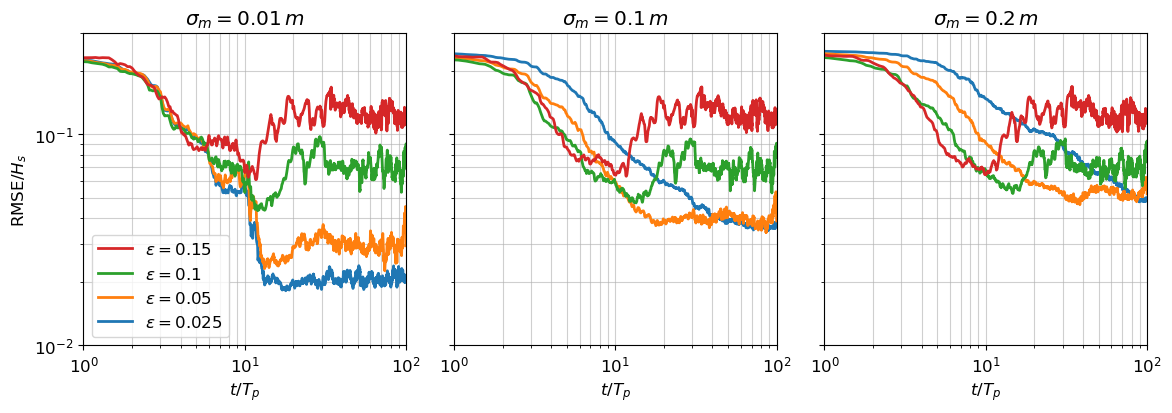

In [ ]:
DATASETS = [
    "data/Hs_1_256_L",
    "data/Hs_2_256_L",
    "data/Hs_3_256_L",
    "data/Hs_4_256_L",
]
TRIALS   = list(range(0, 1))   
SUBDIR   = "GT_HOSM4"

SIGMAS = [0.01, 0.1, 0.2]  
labels = [r"$\varepsilon=0.025$", r"$\varepsilon=0.05$", r"$\varepsilon=0.1$", r"$\varepsilon=0.15$"]

fig, axes = plt.subplots(1, len(SIGMAS), figsize=(4.5*len(SIGMAS), 4.3), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, sigma in zip(axes, SIGMAS):
    all_results = {} 
    t_ref = None

    for ds in DATASETS:
        ds_name = os.path.basename(ds.rstrip("/"))
        all_results[ds_name] = {}

        for tr in TRIALS:
            data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)

            t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
                data_dir,
                n_cycles=1600,
                INFL=1.015, Lc_frac=0.1, use_loc=True,
                Ne=100, sigma_eta=sigma, cutoff=0.8, damping=0.0015,
                x_obs=np.array([125, 375, 625, 875]),
                seed=tr
            )
            all_results[ds_name][tr] = (t_vec, rmse_hist, mae_hist)

    for ds_idx, (ds_name, trial_map) in enumerate(all_results.items()):

        R = np.stack([v[1]for v in trial_map.values()], axis=0)

        mean_rmse = np.sqrt(np.nanmean(R**2, axis=0))          
        std_rmse  = np.nanstd(R, axis=0, ddof=1) if R.shape[0] > 1 else np.zeros_like(mean_rmse)

        ax.plot(t_vec/8, mean_rmse, lw=2.0, label=labels[ds_idx])
        ax.fill_between(t_vec/8, mean_rmse - std_rmse, mean_rmse + std_rmse, alpha=0.25, linewidth=0)


    ax.set_title(rf"$\sigma_m = {sigma}\, m$")
    ax.grid(True, which='both', alpha=0.6)

axes[0].set_ylabel(r"$\mathrm{RMSE}/H_s$")
for ax in axes:
    ax.set_xlabel(r"$t/T_p$")
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 100)
    ax.set_ylim(1e-2, 0.3)

handles, labs = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labels[::-1], loc="lower left")

fig.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

# Nr of Probes

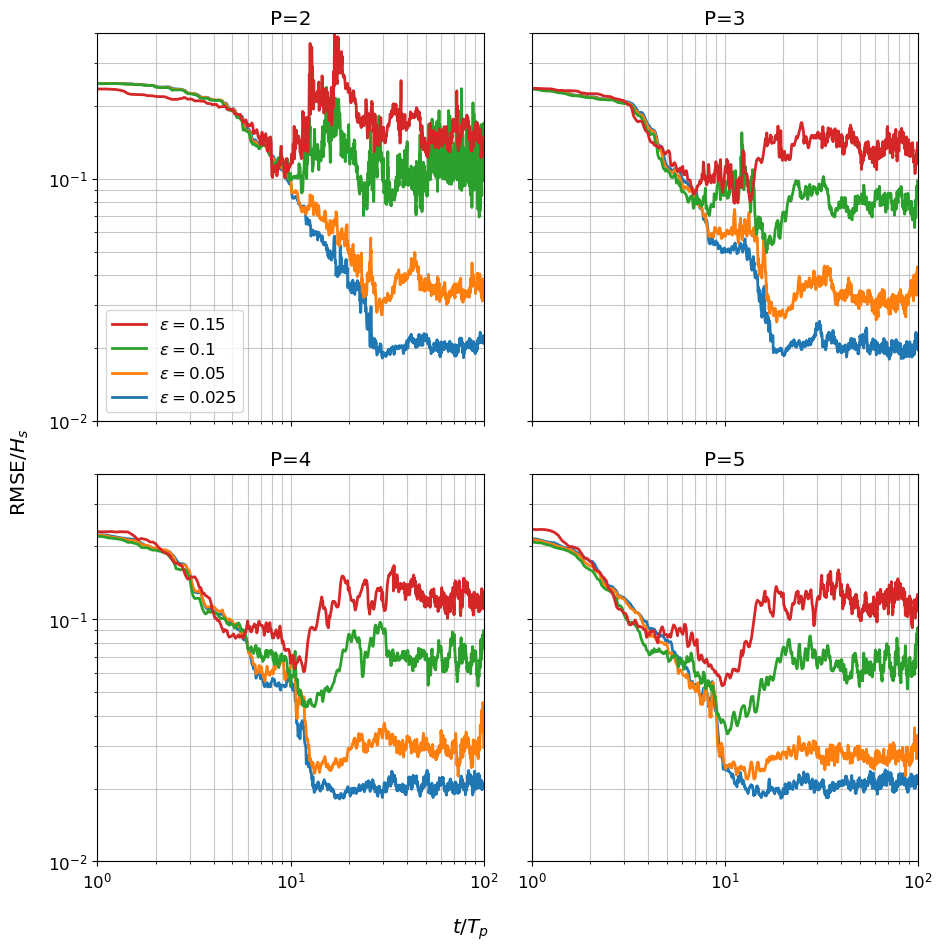

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.6), sharex=True, sharey=True)
axes = axes.ravel()  # [0,1,2,3]

PROBE_COUNTS = [2, 3, 4, 5]
TRIALS   = list(range(0, 1))
filter_caps = {2: 5, 3: 5, 4: 100, 5: 100}

labels = {
    'Hs_1_256_L': r"$\varepsilon=0.025$",
    'Hs_2_256_L': r"$\varepsilon=0.05$",
    'Hs_3_256_L': r"$\varepsilon=0.1$",
    'Hs_4_256_L': r"$\varepsilon=0.15$"
}

Lx = 1000
def make_even_probes(Lx, n_probes):
    """n probes in (0, Lx), first at Lx/(2n)."""
    return (np.arange(n_probes) + 0.5) * (Lx / n_probes)

rmse_stats = {}  # opslaan per #probes

for ax, nP in zip(axes, PROBE_COUNTS):
    x_obs = make_even_probes(Lx, nP)

    for ds in DATASETS:
        ds_name = os.path.basename(ds.rstrip("/"))
        all_results[ds_name] = {}

        for tr in TRIALS:
            data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)
            t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
                data_dir,
                n_cycles=1600,
                INFL=1.015, Lc_frac=0.1, use_loc=True,
                Ne=100, sigma_eta=0.01, cutoff=0.8, 
                damping=0.0015, #filter_cap=0.01,
                x_obs=x_obs,
                seed=tr
            )
            all_results[ds_name][tr] = (t_vec, rmse_hist, mae_hist)

    # --- stats + plot (RMSE) ---
    rmse_stats[nP] = {}
    for ds_name, trial_map in all_results.items():
        T    = t_vec
        # stapel RMSE over trials -> (n_trials, Lmin)
        R = np.stack([v[1] for v in trial_map.values()], axis=0)

        # global RMSE per tijdstap: sqrt(mean(R^2 over runs))
        mean_rmse = np.sqrt(np.mean(R**2, axis=0))
        std_rmse  = R.std(axis=0, ddof=1 if R.shape[0] > 1 else 0)  # spread van per-trial RMSE

        # plot
        ax.plot(T/8, mean_rmse, lw=2.0, label=labels[ds_name])
        ax.fill_between(T/8, mean_rmse - std_rmse, mean_rmse + std_rmse, alpha=0.28, linewidth=0)

    ax.set_title(f"P={nP}")
    ax.grid(True, which='both', alpha=0.7)

# gedeelde assen + limieten
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 100); ax.set_ylim(1e-2, 0.4)

# centrale labels
fig.supylabel(r"$\mathrm{RMSE}/H_s$")
fig.supxlabel(r"$t/T_p$")

# legenda
handles, labs = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labs[::-1], loc="lower left")

fig.tight_layout()
plt.show()


# Random Spacing

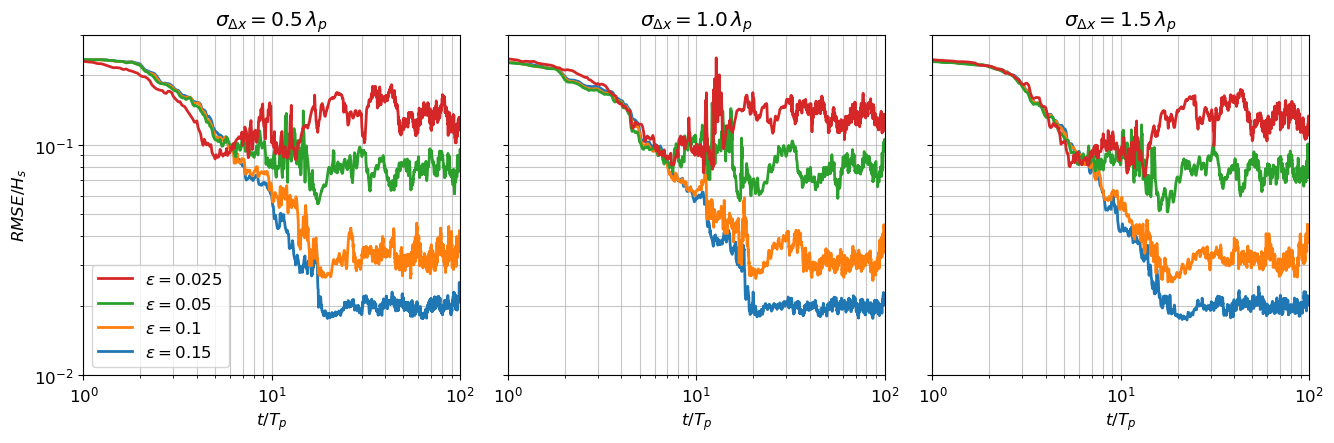

In [ ]:
# ====== settings ======
DATASETS = [
    "data/Hs_1_256_L",
    "data/Hs_2_256_L",
    "data/Hs_3_256_L",
    "data/Hs_4_256_L",
]
TRIALS   = list(range(0, 1))
SUBDIR   = "GT_HOSM4"
labels   = {
    'Hs_1_256_L': r"$\varepsilon=0.025$",
    'Hs_2_256_L': r"$\varepsilon=0.05$",
    'Hs_3_256_L': r"$\varepsilon=0.1$",
    'Hs_4_256_L': r"$\varepsilon=0.15$",
}

# Random probe spacing per trial
sigma_vals   = [50, 100, 150]   # std of spacing [m] for the 3 experiments
N_PROBES     = 4
BASE_SPACING = 250.0                 # mean spacing [m]
START_POS    = 125.0                 # first probe position [m]
USE_CLIP     = False                 # zet True + CLIP_MIN/MAX als je domein wilt clampen
CLIP_MIN, CLIP_MAX = 0.0, 1000.0     # alleen gebruikt als USE_CLIP=True

# opslag: {sigma_dx: {ds_name: {... stats ...}}}
rmse_stats = {}

# ====== plot setup ======
fig, axes = plt.subplots(1, len(sigma_vals), figsize=(4.5*len(sigma_vals), 4.6), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, sigma_dx in zip(axes, sigma_vals):
    rmse_stats[sigma_dx] = {}
    
    for ds in DATASETS:
        ds_name = os.path.basename(ds.rstrip("/"))
        all_results, t_ref = {}, None

        for tr in TRIALS:
            # ---- random 4-probe layout per trial with mean spacing and std=sigma_dx ----
            rng = np.random.default_rng(1000 + tr*97 + int(10*sigma_dx))
            spacings = BASE_SPACING + rng.normal(0.0, sigma_dx, N_PROBES-1)
            x_obs = (START_POS + np.r_[0.0, np.cumsum(spacings)]) % 1000
            if USE_CLIP:
                x_obs = np.clip(x_obs, CLIP_MIN, CLIP_MAX)

            data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)
            t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
                data_dir,
                n_cycles=1600,
                INFL=1.015, Lc_frac=0.10, use_loc=True,
                Ne=100, sigma_eta=0.01, cutoff=0.8, damping=0.0015,
                x_obs=x_obs, seed=tr
            )
            all_results[tr] = (t_vec, rmse_hist, mae_hist)

        # --- stats + plot ---
        M_rmse = np.stack([v[1][:Lmin] for v in all_results.values()], axis=0)  # (n_trials, Lmin)

        mean_rmse = M_rmse.mean(axis=0)
        std_rmse  = M_rmse.std(axis=0, ddof=1 if M_rmse.shape[0] > 1 else 0)

        # plot curve + band
        ax.plot(t_vec/8, mean_rmse, lw=2.0, label=labels[ds_name])
        ax.fill_between(t_vec/8, mean_rmse - std_rmse, mean_rmse + std_rmse, alpha=0.28, linewidth=0)

    ax.set_title(rf"$\sigma_{{\Delta x}} = {sigma_dx/100}\,\lambda_p$")
    ax.grid(True, which='both', alpha=0.7)

axes[0].set_ylabel("$RMSE/H_s$")
for ax in axes:
    ax.set_xlabel(r"$t/T_p$")
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 100);  ax.set_ylim(1e-2, 0.3)

handles, labs = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labs, loc="lower left", ncol=1)

fig.tight_layout()
plt.show()


# Moving 

In [6]:
def run_once_and_get_rmse(
    data_dir,
    n_cycles=1500,
    *,
    v_probe=0.0,          
    M=4,
    INFL=1.005,
    Lc_frac=0.04,
    use_loc=True,
    Ne=100,
    sigma_eta=0.08,
    cutoff=0.8,
    damping=3,
    seed=0,
    filter_cap=None
):
    """

    """
    global k, N

    # Load
    eta_true = np.load(os.path.join(data_dir, 'wavefield_eta_data.npy'))
    t = np.load(os.path.join(data_dir, 'solution_times.npy'))
    x = np.load(os.path.join(data_dir, 'x_coordinates.npy'))

    ETA_TRUE_XT = np.asarray(eta_true[:, 0, :])   # (N, Nt)
    x = np.asarray(x).ravel()
    N = x.size
    k, omega, dx = make_k_omega_grid(x, g=9.81)
    Lx = dx * N
    Hs = 4 * np.sqrt(np.var(ETA_TRUE_XT[:, 0]))

    # Time
    dt = t[1] - t[0]
    Nt = eta_true.shape[-1]
    n_cycles = min(n_cycles, Nt - 1)

# --- Moving probes (constant velocity) ---
    x0 = ((np.arange(M) + 0.5) * (Lx / M)) % Lx

    v_probe = np.asarray(v_probe, dtype=float).ravel()
    if v_probe.size == 1:
        v_arr = np.full(M, float(v_probe[0]))     # same velocity for all probes
    elif v_probe.size == M:
        v_arr = v_probe                            # per-probe velocities
    else:
        raise ValueError("v_probe must be scalar or an array of length M.")

    def idx_obs_at_time(t_now):
        x_now = (x0 + v_arr * t_now) % Lx
        return np.round(x_now / dx).astype(int) % N

    # DA params
    Lc = Lx * Lc_frac
    R = (sigma_eta**2) * np.eye(M)

    # Init ensemble
    rng = np.random.default_rng(seed)
    X = Hs / 20 * rng.normal(size=(N, Ne))
    X -= X.mean(axis=0, keepdims=True)

    # Filter
    if filter_cap is not None:
        hat_mask = new_filter(
            N, cutoff_frac=cutoff,
            damp_strength=np.maximum(damping * Hs**2, filter_cap)
        )
    else:
        hat_mask = new_filter(
            N, cutoff_frac=cutoff,
            damp_strength=damping * Hs**2
        )

    # DA loop
    rmse_hist, mae_hist = [], []
    infl = INFL

    for n in range(n_cycles):
        # Forecast
        for j in range(Ne):
            X[:, j] = lwt_step_eta(X[:, j], omega, k, dt, hat_mask=hat_mask)

        # Truth & obs at t[n+1]
        eta_t = ETA_TRUE_XT[:, n + 1].copy()
        idx_obs = idx_obs_at_time(t[n + 1])

        y_obs = eta_t[idx_obs] + rng.normal(0.0, sigma_eta, size=M)

        # EnKF update
        X = enkf_update_eta(
            X, y_obs, R,
            x_grid=x, idx_obs=idx_obs,
            Lc=Lc, rng=rng
        )

        # Inflation & zero-mean
        mu = X.mean(axis=1, keepdims=True)
        X = mu + infl * (X - mu)
        X -= X.mean(axis=0, keepdims=True)

        # Diagnostics
        ens_mean = X.mean(axis=1)
        rmse = np.sqrt(np.mean((ens_mean - eta_t)**2)) / Hs
        mae  = np.mean(np.abs(ens_mean - eta_t)) / Hs
        rmse_hist.append(rmse)
        mae_hist.append(mae)

        spr = np.sqrt(np.mean(np.var(X, axis=1, ddof=1))) / Hs
        infl = 1.0 if (spr > rmse) else INFL

    return t, np.asarray(rmse_hist), np.asarray(mae_hist)

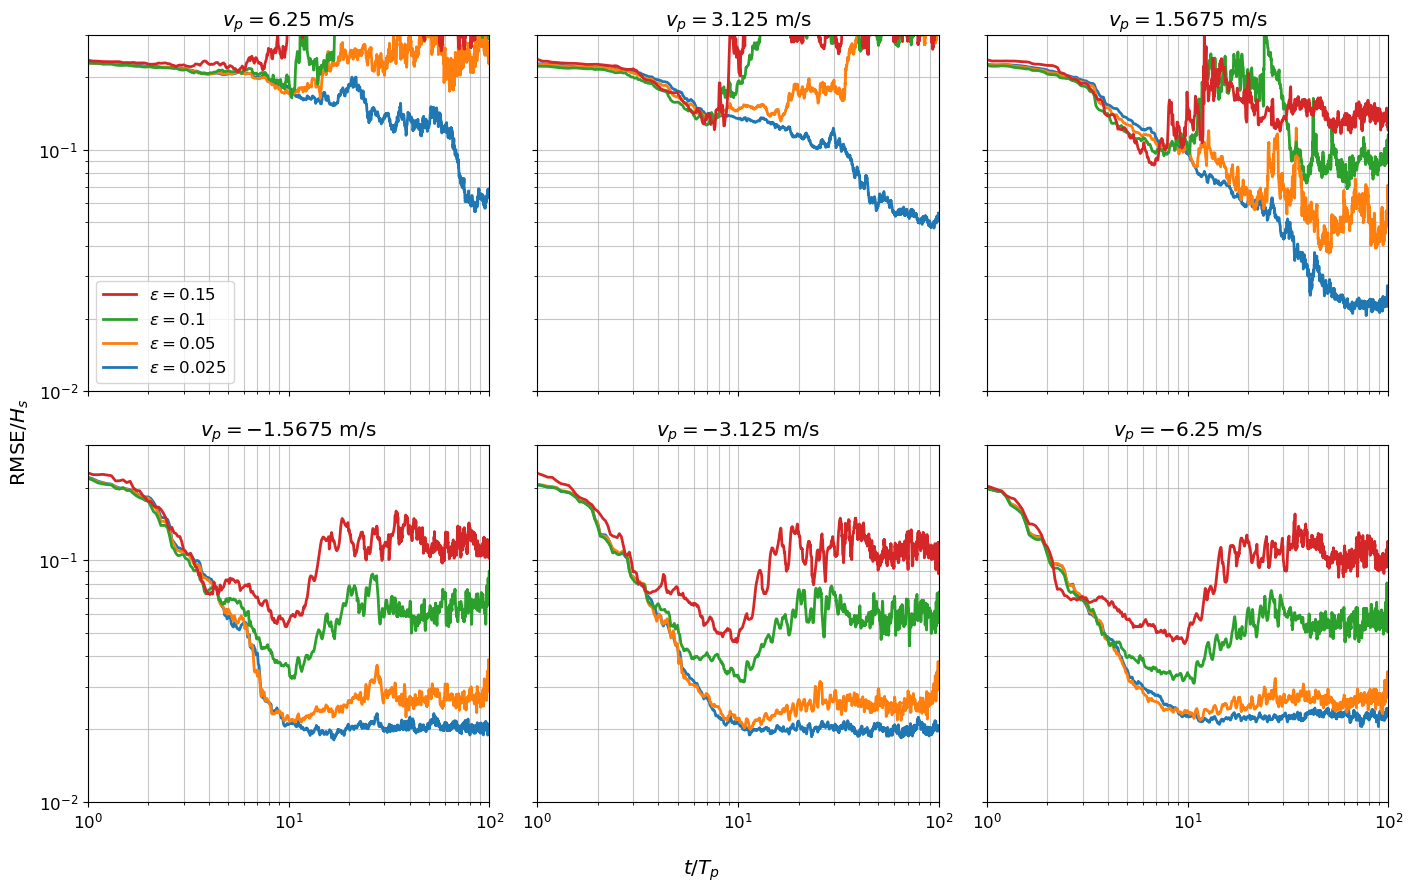

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ====== settings ======
DATASETS = [
    "data/Hs_1_256_L",
    "data/Hs_2_256_L",
    "data/Hs_3_256_L",
    "data/Hs_4_256_L",
]
TRIALS   = list(range(0, 1))
SUBDIR   = "GT_HOSM4"

SIGMA_FIXED = 0.01

labels = {
    'Hs_1_256_L': r"$\varepsilon=0.025$",
    'Hs_2_256_L': r"$\varepsilon=0.05$",
    'Hs_3_256_L': r"$\varepsilon=0.1$",
    'Hs_4_256_L': r"$\varepsilon=0.15$"
}

# ====== 6 velocity cases (m/s) ======
c_peak = 6.25
V_PROBES = [6.25, 3.125, 1.5675, -1.5675, -3.125, -6.25]   # <-- pick your 6
V_LABS   = [f"{v:g}" for v in V_PROBES]

# ====== plot: 2 rows x 3 cols ======
fig, axes = plt.subplots(2, 3, figsize=(14.4, 9.0), sharex=True, sharey=True)
axes = axes.ravel()

rmse_stats = {}  # {v_probe: {ds_name: stats}}

for ax, (V, lab) in zip(axes, zip(V_PROBES, V_LABS)):

    all_results = {}   # {ds_name: {trial: (t_vec, rmse, mae)}}
    t_ref = None

    for ds in DATASETS:
        ds_name = os.path.basename(ds.rstrip("/"))
        all_results[ds_name] = {}

        for tr in TRIALS:
            data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)

            t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
                data_dir,
                n_cycles=1600,
                v_probe=V,             # <--- test velocity here
                M=4,                   # number of moving probes
                INFL=1.015,
                Lc_frac=0.1,
                Ne=100,
                sigma_eta=SIGMA_FIXED,
                cutoff=0.8,
                damping=0.0015,
                seed=tr,
                filter_cap = None
            )

            all_results[ds_name][tr] = (t_vec, rmse_hist, mae_hist)
            if t_ref is None:
                t_ref = t_vec

    # --- stats + plot (RMSE) ---
    rmse_stats[V] = {}

    for ds_name, trial_map in all_results.items():
        Lmin = min(len(v[1]) for v in trial_map.values())
        T    = t_ref[:Lmin]

        R = np.stack([v[1][:Lmin] for v in trial_map.values()], axis=0)

        mean_rmse = np.sqrt(np.mean(R**2, axis=0))
        std_rmse  = R.std(axis=0, ddof=1 if R.shape[0] > 1 else 0)

        ax.plot(T/8, mean_rmse, lw=2.0, label=labels[ds_name])
        if np.any(std_rmse):
            ax.fill_between(T/8, mean_rmse - std_rmse, mean_rmse + std_rmse,
                            alpha=0.28, linewidth=0)

    ax.set_title(rf"$v_p = {lab}\ \mathrm{{m/s}}$")
    ax.grid(True, which='both', alpha=0.7)

# shared axes + limits (match your style)
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 100); ax.set_ylim(1e-2, 0.3)

fig.supylabel(r"$\mathrm{RMSE}/H_s$")
fig.supxlabel(r"$t/T_p$")

# legend once (reversed like you did)
handles, labs = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labs[::-1], loc="lower left")

fig.tight_layout()
plt.show()

# Different Directions

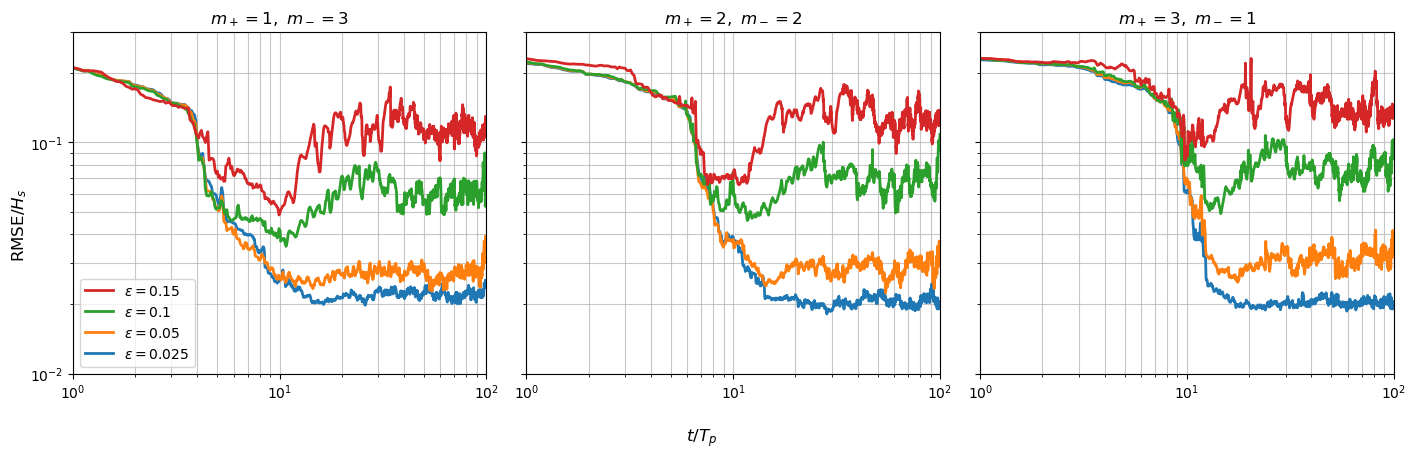

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ====== settings ======
DATASETS = [
    "data/Hs_1_256_L",
    "data/Hs_2_256_L",
    "data/Hs_3_256_L",
    "data/Hs_4_256_L",
]
TRIALS   = list(range(0, 1))
SUBDIR   = "GT_HOSM4"

SIGMA_FIXED = 0.01

labels = {
    'Hs_1_256_L': r"$\varepsilon=0.025$",
    'Hs_2_256_L': r"$\varepsilon=0.05$",
    'Hs_3_256_L': r"$\varepsilon=0.1$",
    'Hs_4_256_L': r"$\varepsilon=0.15$"
}

# ====== choose speed magnitude (m/s) ======
c_peak = 6.25
V = c_peak  # set magnitude once

def v_arr_from_split(V, n_pos, n_neg):
    M = n_pos + n_neg
    if M <= 0:
        raise ValueError("Need at least 1 probe.")
    return np.array([+V]*n_pos + [-V]*n_neg, dtype=float)

# 3 cases you asked for
CASES = [(1, 3), (2, 2), (3, 1)]  # (n_pos, n_neg)

# ====== plot: 1 row x 3 cols ======
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.6), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, (n_pos, n_neg) in zip(axes, CASES):
    v_probe = v_arr_from_split(V, n_pos, n_neg)
    M = v_probe.size  # should be 4

    all_results = {}
    t_ref = None

    for ds in DATASETS:
        ds_name = os.path.basename(ds.rstrip("/"))
        all_results[ds_name] = {}

        for tr in TRIALS:
            data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)

            t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
                data_dir,
                n_cycles=1600,
                v_probe=v_probe,   # <--- per-probe velocities: [+V,...,-V,...]
                M=M,
                INFL=1.015,
                Lc_frac=0.1,
                Ne=100,
                sigma_eta=SIGMA_FIXED,
                cutoff=0.8,
                damping=0.0015,
                seed=tr,
                filter_cap=None
            )

            all_results[ds_name][tr] = (t_vec, rmse_hist, mae_hist)
            if t_ref is None:
                t_ref = t_vec

    # --- stats + plot (RMSE) ---
    for ds_name, trial_map in all_results.items():
        Lmin = min(len(v[1]) for v in trial_map.values())
        T    = t_ref[:Lmin]

        R = np.stack([v[1][:Lmin] for v in trial_map.values()], axis=0)
        mean_rmse = np.sqrt(np.mean(R**2, axis=0))
        std_rmse  = R.std(axis=0, ddof=1 if R.shape[0] > 1 else 0)

        ax.plot(T/8, mean_rmse, lw=2.0, label=labels[ds_name])
        if np.any(std_rmse):
            ax.fill_between(T/8, mean_rmse - std_rmse, mean_rmse + std_rmse,
                            alpha=0.28, linewidth=0)

    ax.set_title(rf"$m_+={n_pos},\ m_-={n_neg}$")
    ax.grid(True, which='both', alpha=0.7)

# shared axes + limits
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 100); ax.set_ylim(1e-2, 0.3)

fig.supylabel(r"$\mathrm{RMSE}/H_s$")
fig.supxlabel(r"$t/T_p$")

handles, labs_ = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labs_[::-1], loc="lower left")

fig.tight_layout()
plt.show()

# Assimilation frequency

In [3]:
def run_once_and_get_rmse(
    data_dir,
    n_cycles=1500,
    *,
    assim_interval=1,              # <--- NEW
    INFL=1.015,
    Lc_frac=0.1,
    use_loc=True,
    Ne=100,
    sigma_eta=0.01,
    cutoff=0.8,
    damping=0.0015,
    x_obs=np.array([125, 375, 625, 875]),
    seed=0,
    filter_cap=None
):
    global k, N  # Globals

    eta_true = np.load(os.path.join(data_dir, 'wavefield_eta_data.npy'))
    t = np.load(os.path.join(data_dir, 'solution_times.npy'))
    x = np.load(os.path.join(data_dir, 'x_coordinates.npy'))

    # Reference
    ETA_TRUE_XT = np.asarray(eta_true[:, 0, :])   # (N, Nt)

    # Setup From data
    x = np.asarray(x).ravel()
    N = x.size
    k, omega, dx = make_k_omega_grid(x, g=9.81)
    Lx = dx * N
    Hs = 4*np.sqrt(np.var(ETA_TRUE_XT[:, 0]))     # Calculate Hs from data

    steepness = 2*np.pi**2*Hs/(9.81*8**2)

    # Time
    dt = t[1] - t[0]
    Nt = eta_true.shape[-1]
    n_cycles = min(n_cycles, Nt-1)

    # Probes
    idx_obs = np.round(x_obs / dx).astype(int) % N
    M = idx_obs.size

    # DA params
    Lc = Lx * Lc_frac
    R = (sigma_eta**2) * np.eye(M)

    # Init ensemble
    rng = np.random.default_rng(seed)
    X = Hs/20 * rng.normal(size=(N, Ne))
    X -= X.mean(axis=0, keepdims=True)

    # Filter
    if filter_cap is not None:
        hat_mask = new_filter(N, cutoff_frac=cutoff,
                              damp_strength=np.maximum(filter_cap, damping*Hs**2))
    else:
        hat_mask = new_filter(N, cutoff_frac=cutoff, damp_strength=damping*Hs**2)

    # DA loop
    rmse_hist = []
    mae_hist = []

    inflation = INFL

    # optional: sanity
    if assim_interval < 1:
        raise ValueError("assim_interval must be >= 1")

    for n in range(n_cycles):
        # Forecast every step
        for j in range(Ne):
            X[:, j] = lwt_step_eta(X[:, j], omega, k, dt, hat_mask=hat_mask)

        # Truth at this step (used for scoring every step)
        eta_t = ETA_TRUE_XT[:, n+1].copy()

        # Assimilate only every `assim_interval` steps
        do_assim = (n % assim_interval) == 0
        if do_assim:
            y_obs = eta_t[idx_obs] + rng.normal(0.0, sigma_eta, size=M)

            X = enkf_update_eta(
                X, y_obs, R,
                x_grid=x, idx_obs=idx_obs,
                Lc=Lc, rng=rng
            )

            # Inflation & zero-mean only when we update (typical)
            mu = X.mean(axis=1, keepdims=True)
            X = mu + inflation*(X - mu)
            X -= X.mean(axis=0, keepdims=True)

        # Diagnostics (still every step)
        ens_mean = X.mean(axis=1)

        rmse = np.sqrt(np.mean((ens_mean - eta_t)**2)) / Hs
        mae  = np.mean(np.abs(ens_mean - eta_t)) / Hs
        spr  = np.sqrt(np.mean(np.var(X[:, :], axis=1, ddof=1))) / Hs

        # Only adapt inflation when you actually assimilate (otherwise it reacts to free forecasts)
        if do_assim:
            inflation = 1.0 if (spr > rmse) else INFL

        rmse_hist.append(rmse)
        mae_hist.append(mae)

    return t[:n_cycles], np.asarray(rmse_hist), np.asarray(mae_hist)

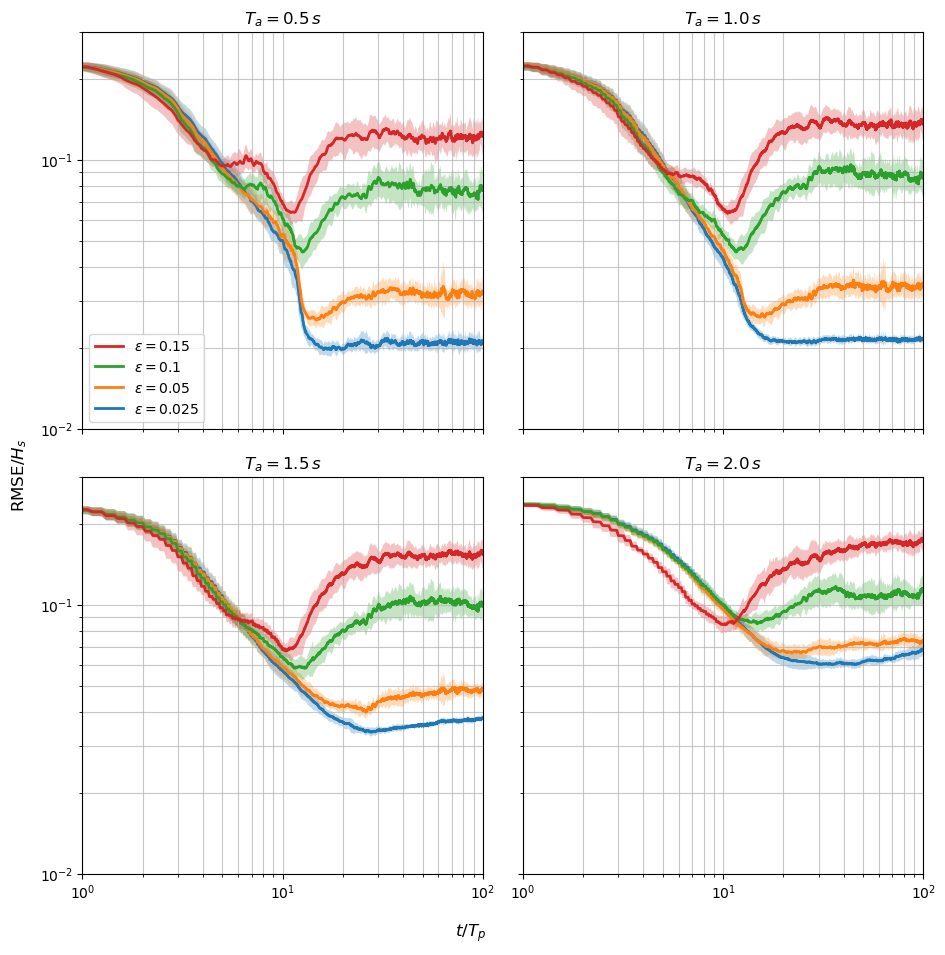

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ====== settings ======
DATASETS = [
    "data/Hs_1_256_L",
    "data/Hs_2_256_L",
    "data/Hs_3_256_L",
    "data/Hs_4_256_L",
]
TRIALS   = list(range(0, 20))
SUBDIR   = "GT_HOSM4"

SIGMA_FIXED = 0.01
ASSIM_DTS   = [0.5, 1.0, 1.5, 2.0]     # seconds between EnKF updates
ASSIM_LABS  = ["1/16", "1/8", "1/5.3", "1/4"]
X_OBS       = np.array([125, 375, 625, 875])

labels = {
    'Hs_1_256_L': r"$\varepsilon=0.025$",
    'Hs_2_256_L': r"$\varepsilon=0.05$",
    'Hs_3_256_L': r"$\varepsilon=0.1$",
    'Hs_4_256_L': r"$\varepsilon=0.15$"
}

# --- choose 4 cases ---
ASSIM_INTERVALS = [1, 2, 3, 4]
ASSIM_LABS      = ["1", "2", "3", "4"]   # shown as multiples of dt (or "Δn")

# ====== experiment in exact 2×2 grid-format (RMSE) ======
fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.6), sharex=True, sharey=True)
axes = axes.ravel()

rmse_stats = {}  # {assim_interval: {ds_name: stats}}

for ax, (ASSIM_INT, lab) in zip(axes, zip(ASSIM_INTERVALS, ASSIM_LABS)):

    all_results = {}   # {ds_name: {trial: (t_vec, rmse, mae)}}
    t_ref = None

    for ds in DATASETS:
        ds_name = os.path.basename(ds.rstrip("/"))
        all_results[ds_name] = {}

        for tr in TRIALS:
            data_dir = os.path.join(os.getcwd(), ds, f"trial_{tr}", SUBDIR)

            t_vec, rmse_hist, mae_hist = run_once_and_get_rmse(
                data_dir,
                n_cycles=1600,
                assim_interval=ASSIM_INT,      # <--- HERE
                INFL=1.015,
                Lc_frac=0.1,
                Ne=100,
                sigma_eta=SIGMA_FIXED,
                cutoff=0.8,
                damping=0.0015,
                x_obs=X_OBS,
                seed=tr,
                filter_cap=0.001 * ASSIM_INT ** 2
            )

            all_results[ds_name][tr] = (t_vec, rmse_hist, mae_hist)
            if t_ref is None:
                t_ref = t_vec

    # --- stats + plot (RMSE) ---
    rmse_stats[ASSIM_INT] = {}

    for ds_name, trial_map in all_results.items():
        Lmin = min(len(v[1]) for v in trial_map.values())
        T    = t_ref[:Lmin]
        i0   = Lmin // 2  # (unused here but kept consistent with your template)

        R = np.stack([v[1][:Lmin] for v in trial_map.values()], axis=0)

        mean_rmse = np.sqrt(np.mean(R**2, axis=0))
        std_rmse  = R.std(axis=0, ddof=1 if R.shape[0] > 1 else 0)

        ax.plot(T/8, mean_rmse, lw=2.0, label=labels[ds_name])
        if np.any(std_rmse):
            ax.fill_between(T/8, mean_rmse - std_rmse, mean_rmse + std_rmse,
                            alpha=0.28, linewidth=0)

    ax.set_title(rf"$T_a = {0.5 * ASSIM_INT}\,s$")   # assimilation every lab steps
    ax.grid(True, which='both', alpha=0.7)

# shared axes + limits
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 100); ax.set_ylim(1e-2, 0.3)

fig.supylabel(r"$\mathrm{RMSE}/H_s$")
fig.supxlabel(r"$t/T_p$")

handles, labs = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labs[::-1], loc="lower left")

fig.tight_layout()
plt.show()